In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import os

In [ ]:
# Downloading latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
os.listdir("/kaggle/input/telco-customer-churn")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df[df['TotalCharges'] == ' '].shape

(11, 21)

In [ ]:
# Convert TotalCharges to numeric, coercing blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verify missing values
df['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
# Impute missing TotalCharges with 0 (tenure = 0 customers) (where some can have blank strings '' not NAN)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
df = df.drop(columns=['customerID'])

In [ ]:
# remobing labels (churn)
churn_labels = df['Churn']
df = df.drop(columns=['Churn'])

In [ ]:
# numerical vs categorical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

cat_cols = [col for col in df.columns if col not in num_cols]

In [ ]:
num_cols, cat_cols

(['tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [ ]:
# one hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

In [ ]:
# converting back to dataframe for readability
import numpy as np

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns,
    index=df_encoded.index
)

In [ ]:
X_scaled.shape

(7043, 30)

In [ ]:
# checking for mean=0 and std=1
X_scaled.describe().round(2)

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,...,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,...,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.32,-1.55,-1.01,-1.01,-0.44,-0.97,-0.65,-3.05,-0.33,-0.85,...,-0.53,-0.79,-0.53,-0.80,-0.51,-0.56,-1.21,-0.53,-0.71,-0.54
25%,-0.95,-0.97,-0.83,-1.01,-0.44,-0.97,-0.65,0.33,-0.33,-0.85,...,-0.53,-0.79,-0.53,-0.80,-0.51,-0.56,-1.21,-0.53,-0.71,-0.54
50%,-0.14,0.19,-0.39,0.99,-0.44,-0.97,-0.65,0.33,-0.33,-0.85,...,-0.53,-0.79,-0.53,-0.80,-0.51,-0.56,0.83,-0.53,-0.71,-0.54
75%,0.92,0.83,0.66,0.99,-0.44,1.03,1.53,0.33,-0.33,1.17,...,-0.53,1.27,-0.53,1.26,-0.51,-0.56,0.83,-0.53,1.41,-0.54
max,1.61,1.79,2.83,0.99,2.27,1.03,1.53,0.33,3.05,1.17,...,1.90,1.27,1.90,1.26,1.94,1.78,0.83,1.90,1.41,1.84


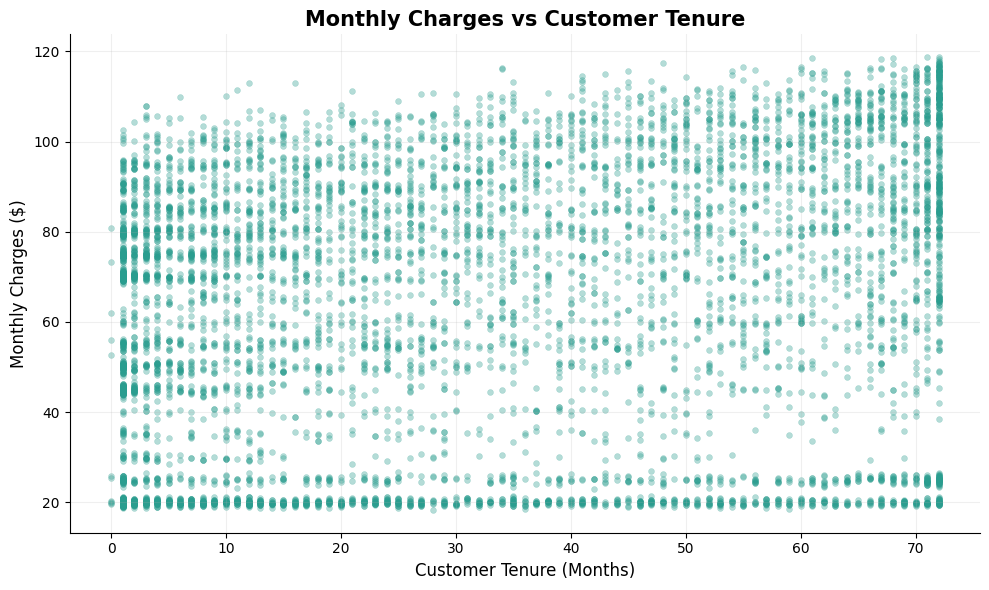

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    color='#2A9D8F',
    alpha=0.35,
    s=18,
    edgecolor=None
)

plt.title('Monthly Charges vs Customer Tenure', fontsize=15, weight='bold')
plt.xlabel('Customer Tenure (Months)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.grid(alpha=0.2)
sns.despine()

plt.tight_layout()
plt.show()

# principal component analysis

In [ ]:
from sklearn.decomposition import PCA

# PCA keeping 90% variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(7043, 15)

In [ ]:
pca.explained_variance_ratio_.sum()

np.float64(0.9179022843114946)

# K-means algorithm

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    sil_scores[k] = silhouette_score(X_pca, labels)

sil_scores

{2: np.float64(0.3641061597771481),
 3: np.float64(0.23915570480974868),
 4: np.float64(0.26209143459582634),
 5: np.float64(0.21643870300877457),
 6: np.float64(0.21374938794652554),
 7: np.float64(0.15259728326693486),
 8: np.float64(0.15009468363902206),
 9: np.float64(0.14789357368827635),
 10: np.float64(0.1532024350542463)}

We evaluated k from 2 to 10 using silhouette score. The data showed a clear maximum at k=2, indicating two dominant customer behavior groups. Higher k values reduced cluster separation

In [ ]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)

In [ ]:
X_scaled['cluster'] = kmeans_labels

In [ ]:
X_scaled['cluster'].value_counts()

,count
cluster,
0,5517
1,1526


In [ ]:
df_profile = df.copy()
df_profile['cluster'] = kmeans_labels

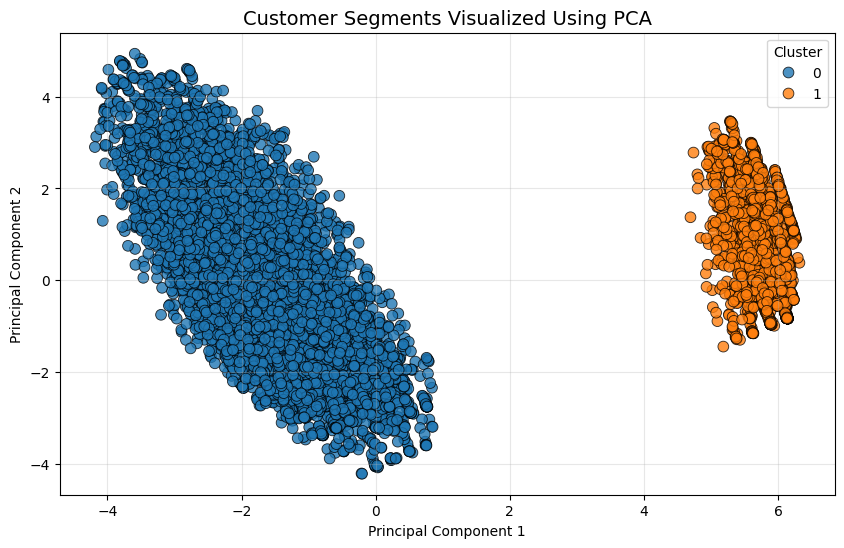

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with the first two principal components
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': kmeans_labels
})

# Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette = ['#1f77b4', '#ff7f0e'],
    s=60,
    alpha=0.8,
    edgecolor='black'
)

plt.title('Customer Segments Visualized Using PCA', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)

plt.show()

# Cluster profiling


we here use the original features because, use used scaled data and PCA components which are not human readable.

In [ ]:
# attaching cluster labels to original data
df_profile = df.copy()
df_profile['cluster'] = kmeans_labels

In [ ]:
df_profile.groupby('cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
cluster,,,
0,32.875657,76.844254,2727.031684
1,30.547182,21.079194,662.604784


In [ ]:
df_profile.groupby('cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].median()

,tenure,MonthlyCharges,TotalCharges
cluster,,,
0,30.0,79.45,2135.5
1,25.0,20.15,519.2


In [ ]:
pd.crosstab(
    df_profile['Contract'],
    df_profile['cluster'],
    normalize='columns'
) * 100

cluster,0,1
Contract,,
Month-to-month,60.739532,34.338139
One year,20.101504,23.853211
Two year,19.158963,41.808650


In [ ]:
pd.crosstab(
    df_profile['PaymentMethod'],
    df_profile['cluster'],
    normalize='columns'
) * 100

cluster,0,1
PaymentMethod,,
Bank transfer (automatic),21.968461,21.756225
Credit card (automatic),21.587819,21.690695
Electronic check,40.656154,7.994758
Mailed check,15.787566,48.558322


In [ ]:
pd.crosstab(
    df_profile['InternetService'],
    df_profile['cluster'],
    normalize='columns'
) * 100

cluster,0,1
InternetService,,
DSL,43.882545,0.0
Fiber optic,56.117455,0.0
No,0.000000,100.0


KMeans found a service-based split, not a value-based split.

In [ ]:
df["Cluster"] = kmeans_labels

# Clsuter 0

In [ ]:
from sklearn.ensemble import IsolationForest

cluster0_X = X_scaled[X_scaled['cluster'] == 0].drop(columns=['cluster'])

iso0 = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly0 = iso0.fit_predict(cluster0_X)

contamination= 0.05, assumption of 0.05 unusual customers

# Cluster 1

In [ ]:
cluster1_X = X_scaled[X_scaled['cluster'] == 1].drop(columns=['cluster'])

iso1 = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly1 = iso1.fit_predict(cluster1_X)

In [ ]:
df_profile['anomaly'] = 1  # default: normal

df_profile.loc[df_profile['cluster'] == 0, 'anomaly'] = anomaly0
df_profile.loc[df_profile['cluster'] == 1, 'anomaly'] = anomaly1

In [ ]:
df_profile.groupby(['cluster', 'anomaly']).size()

cluster  anomaly
0        -1          276
          1         5241
1        -1           77
          1         1449
dtype: int64

In [ ]:
dashboard_df = df_profile.copy()

In [ ]:
dashboard_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Cluster', 'cluster', 'anomaly'],
      dtype='object')

In [ ]:
churn_labels.head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


In [ ]:
dashboard_df["Churn"] = churn_labels

In [ ]:
dashboard_df[["cluster","anomaly","Churn"]].head()

,cluster,anomaly,Churn
0,0,1,No
1,0,1,No
2,0,1,Yes
3,0,1,No
4,0,1,Yes


In [ ]:
dashboard_df["cluster"].value_counts()

,count
cluster,
0,5517
1,1526


In [ ]:
pd.crosstab(
    dashboard_df["cluster"],
    dashboard_df["Churn"],
    normalize="index"
).round(4) * 100

Churn,No,Yes
cluster,,
0,68.17,31.83
1,92.60,7.40


In [ ]:
dashboard_df.groupby("cluster")[
    ["MonthlyCharges","TotalCharges","tenure"]
].mean().round(2)

,MonthlyCharges,TotalCharges,tenure
cluster,,,
0,76.84,2727.03,32.88
1,21.08,662.60,30.55


In [ ]:
pd.crosstab(
    dashboard_df["cluster"],
    dashboard_df["Contract"],
    normalize="index"
).round(4) * 100

Contract,Month-to-month,One year,Two year
cluster,,,
0,60.74,20.10,19.16
1,34.34,23.85,41.81


In [ ]:
dashboard_df.to_csv("customer_segmentation_dashboard.csv", index=False)

In [ ]:
dashboard_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cluster,cluster,anomaly,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,1,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,0,1,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,1,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,1,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,1,Yes


In [ ]:
from google.colab import files
files.download("customer_segmentation_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>